<a href="https://colab.research.google.com/github/dbright123/Dbot-Advance/blob/main/market_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import MetaTrader5 as mt5
import numpy as np
import pandas as pd

print("MetaTrader5 package author: ",mt5.__author__)
print("MetaTrader5 package version: ",mt5.__version__)

trade_active = mt5.initialize("C:\\Program Files\\MetaTrader 5\\terminal64.exe")

print(trade_active)

if not trade_active:
    print('Initialization failed, check internet connection. You must have Meta Trader 5 installed.')
    mt5.shutdown()

else:
    print(mt5.account_info()._asdict())
    print("\n")
    print(mt5.terminal_info()._asdict())
    print("\n")
    print(mt5.symbols_total())

account = mt5.account_info()
terminal = mt5.terminal_info()

print(account.equity)

if(terminal.connected == True or terminal.trade_allowed == True):
    print("AI is successfully functional")
else:
    print("Please make sure metatrade 5 has internet and algo Trade is Turn On")

MetaTrader5 package author:  MetaQuotes Ltd.
MetaTrader5 package version:  5.0.5200
True
{'login': 32122224, 'trade_mode': 0, 'leverage': 1000, 'limit_orders': 50, 'margin_so_mode': 0, 'trade_allowed': True, 'trade_expert': True, 'margin_mode': 2, 'currency_digits': 2, 'fifo_close': False, 'balance': 10000.0, 'credit': 0.0, 'profit': -814.56, 'equity': 9185.44, 'margin': 7.95, 'margin_free': 9177.49, 'margin_level': 115540.12578616352, 'margin_so_call': 100.0, 'margin_so_so': 50.0, 'margin_initial': 0.0, 'margin_maintenance': 0.0, 'assets': 0.0, 'liabilities': 0.0, 'commission_blocked': 0.0, 'name': 'Micheal Bright Omage', 'server': 'Deriv-Demo', 'currency': 'USD', 'company': 'Deriv.com Limited'}


{'community_account': False, 'community_connection': False, 'connected': True, 'dlls_allowed': False, 'trade_allowed': False, 'tradeapi_disabled': False, 'email_enabled': False, 'ftp_enabled': False, 'notifications_enabled': False, 'mqid': True, 'build': 5660, 'maxbars': 100000000, 'codepage

In [2]:
t_s = "BTCUSD"
market = mt5.copy_rates_from_pos(t_s, mt5.TIMEFRAME_H1, 0, 9000000)
#display(market)
print(market.shape)

print(t_s)

# GOLD is 5 mins while GBPUSD is 15 mins

data = []
for i in range(len(market)):
    data.append([market[i][0],market[i][1],market[i][2],market[i][3],market[i][4],market[i][5]])
df = pd.DataFrame(data, columns=["time","open", "high","low", "close","volume"])
df.to_csv("Generated"+t_s+" dbot.csv", index=False)
print("Current Action Done")

(83365,)
BTCUSD
Current Action Done


In [3]:
market

array([(1300917600, 8.3000000e-01, 9.0000000e-01, 8.3000000e-01, 8.7000000e-01, 14009,    0, 0),
       (1301004000, 8.7000000e-01, 8.9000000e-01, 8.6000000e-01, 8.8000000e-01,  4819,    0, 0),
       (1301090400, 8.8000000e-01, 9.1000000e-01, 8.4000000e-01, 8.6000000e-01, 11756,    0, 0),
       ...,
       (1775970000, 7.1427157e+04, 7.1748627e+04, 7.1369215e+04, 7.1664377e+04, 14419, 2424, 0),
       (1775973600, 7.1664380e+04, 7.1719463e+04, 7.1600406e+04, 7.1617486e+04, 12711, 2424, 0),
       (1775977200, 7.1617486e+04, 7.1617486e+04, 7.1541786e+04, 7.1569740e+04,  1451, 2424, 0)],
      dtype=[('time', '<i8'), ('open', '<f8'), ('high', '<f8'), ('low', '<f8'), ('close', '<f8'), ('tick_volume', '<u8'), ('spread', '<i4'), ('real_volume', '<u8')])

In [4]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

import warnings

import joblib
from extra_function import RobustPriceLabelerV3, engineer_features, plot_signals, predict_and_plot_signals

#warnings.filterwarnings('ignore')

In [5]:


print("="*70)
print("TRADING SIGNAL CLASSIFICATION SYSTEM")
print("="*70)

# Step 1: Load data from Excel
print("\nStep 1: Loading data from Excel file...")
t_symbol = ["XAUUSD","BTCUSD","GBPUSD","Volatility 100 (1s) Index","Step Index"] #GPBUSD is 1 hour and XAUUSD is 15 min data
n = 1
m_label = "Generated"+t_symbol[n]






TRADING SIGNAL CLASSIFICATION SYSTEM

Step 1: Loading data from Excel file...


In [6]:

df = pd.read_csv(m_label+ " dbot.csv")
df = engineer_features(df[:-200])

e:\GitHub\Dbot-Advance\extra_function.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['time'] = pd.to_datetime(df['time'], unit='s', errors='coerce')
e:\GitHub\Dbot-Advance\extra_function.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['month'] = df['time'].dt.month
e:\GitHub\Dbot-Advance\extra_function.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentatio

In [7]:
df

,open,high,low,close,volume,month,day,hour,day_of_week
0,0.830,0.900,0.830,0.870,14009,3,23,22,2
1,0.870,0.890,0.860,0.880,4819,3,24,22,3
2,0.880,0.910,0.840,0.860,11756,3,25,22,4
3,0.830,0.870,0.820,0.820,5337,3,26,22,5
4,0.820,0.850,0.760,0.800,12565,3,27,22,6
...,...,...,...,...,...,...,...,...,...
83160,66760.733,66879.077,66450.813,66598.235,17486,4,3,1,4
83161,66598.073,66725.484,66238.407,66503.268,19329,4,3,2,4
83162,66503.268,66697.547,66459.543,66548.833,14980,4,3,3,4
83163,66548.833,66664.871,66466.446,66576.988,14267,4,3,4,4


In [8]:

labeler = RobustPriceLabelerV3(
                atr_period      = 14,
                zigzag_atr_mult = 0.2,
                hold_bars       = 1,
                min_streak      = 0.01,
                target_hold_pct = 0.01 )


df = labeler.label(df)
print(df[["close", "label", "label_name", "label_conf"]].tail(20))

"""
from extra_function import RobustPriceLabelerV4, RobustPriceLabelerV5


labeler = RobustPriceLabelerV4(
    # ----- Core zigzag -----
    atr_period       = 14,
    zigzag_atr_mult  = 0.5,
    hold_bars        = 2,
    min_streak       = 2,
    target_hold_pct  = 0.30,
    # ----- S/R zone filter (backward) -----
    sr_lookback      = 3,       # track last 3 swing H and 3 swing L
    zone_mult        = 1.0,     # block within 1 ATR of any S/R level
    # ----- Triple barrier (forward) -----
    profit_mult      = 1.0,     # TP = entry +/- 1.5 x ATR
    stop_mult        = 1.0,     # SL = entry -/+ 1.0 x ATR
    max_confirm_bars = 10,      # look up to 20 bars (100 min) ahead
    # ----- Optional EMA momentum gate -----
    use_momentum_gate= False,   # set True for stricter trend-aligned labels
    ema_fast         = 8,
    ema_slow         = 21,
    ema_slope_tol    = 0.5,
)

df = labeler.label(df)
print(
    df[["close", "label", "label_name", "label_conf",
            "zone_locked", "barrier_locked"]].tail(20).to_string()
)

from extra_function import RobustPriceLabelerV4, RobustPriceLabelerV5
labeler = RobustPriceLabelerV5(
    # Core zigzag
    atr_period       = 14,
    zigzag_atr_mult  = 0.5,
    # S/R zone filter (backward)
    sr_lookback      = 3,       # track last 3 swing highs and 3 swing lows
    zone_mult        = 1.0,     # flip within 1 ATR of any S/R level
    # Triple-barrier (forward)
    profit_mult      = 1.5,     # TP = entry +/- 1.5 x ATR
    stop_mult        = 1.0,     # SL = entry -/+ 1.0 x ATR
    max_confirm_bars = 20,      # 20 bars forward = 100 min on 5-min chart
    # EMA momentum gate (optional)
    use_momentum_gate= True,   # set True for trend-aligned labeling
    ema_fast         = 8,
    ema_slow         = 21,
    ema_slope_tol    = 0.5,
)

df = labeler.label(df)

print(
    df[[
        "close", "label", "label_name", "label_conf",
        "zone_flipped", "barrier_flipped", "any_flipped", "partial_forward"
    ]].tail(20).to_string()
)

# Verify no HOLDs exist
assert df["label"].isin([1, 2]).all(), "ERROR: HOLD labels found!"
print("\nValidation passed: all labels are binary (1=buy, 2=sell)")
 """

Computing ATR...
Finding zigzag pivots...
   41208 pivots found
Assigning zone labels...
Enforcing class balance...
Computing confidence scores...

── Label Distribution ──────────────────────────
  buy : 27,055  ( 32.5%)  █████████████
  sell: 25,049  ( 30.1%)  ████████████
  hold: 31,061  ( 37.3%)  ██████████████
────────────────────────────────────────────────
           close  label label_name  label_conf
83145  66422.892      2       sell       0.422
83146  66179.486      2       sell       0.642
83147  66013.700      2       sell       0.682
83148  66226.319      0       hold       0.674
83149  66821.167      1        buy       0.888
83150  66808.580      1        buy       0.636
83151  67051.875      1        buy       0.745
83152  66640.097      1        buy       0.562
83153  66941.100      1        buy       0.655
83154  66942.376      1        buy       0.383
83155  66905.573      1        buy       0.279
83156  66909.885      1        buy       0.232
83157  66952.888      1

'\nfrom extra_function import RobustPriceLabelerV4, RobustPriceLabelerV5\n\n\nlabeler = RobustPriceLabelerV4(\n    # ----- Core zigzag -----\n    atr_period       = 14,\n    zigzag_atr_mult  = 0.5,\n    hold_bars        = 2,\n    min_streak       = 2,\n    target_hold_pct  = 0.30,\n    # ----- S/R zone filter (backward) -----\n    sr_lookback      = 3,       # track last 3 swing H and 3 swing L\n    zone_mult        = 1.0,     # block within 1 ATR of any S/R level\n    # ----- Triple barrier (forward) -----\n    profit_mult      = 1.0,     # TP = entry +/- 1.5 x ATR\n    stop_mult        = 1.0,     # SL = entry -/+ 1.0 x ATR\n    max_confirm_bars = 10,      # look up to 20 bars (100 min) ahead\n    # ----- Optional EMA momentum gate -----\n    use_momentum_gate= False,   # set True for stricter trend-aligned labels\n    ema_fast         = 8,\n    ema_slow         = 21,\n    ema_slope_tol    = 0.5,\n)\n\ndf = labeler.label(df)\nprint(\n    df[["close", "label", "label_name", "label_conf

In [9]:

"""Analyze the labeling results"""
print(f"Total samples: {len(df)}")
print(f"Buy labels: {(df['label'] == 1).sum()} ({((df['label'] == 1).sum()/len(df))*100:.1f}%)")
print(f"Sell labels: {(df['label'] == 2).sum()} ({((df['label'] == 2).sum()/len(df))*100:.1f}%)")
print(f"Hold labels: {(df['label'] == 0).sum()} ({((df['label'] == 0).sum()/len(df))*100:.1f}%)")



Total samples: 83165
Buy labels: 27055 (32.5%)
Sell labels: 25049 (30.1%)
Hold labels: 31061 (37.3%)



Step 5: Visualizing trading signals...


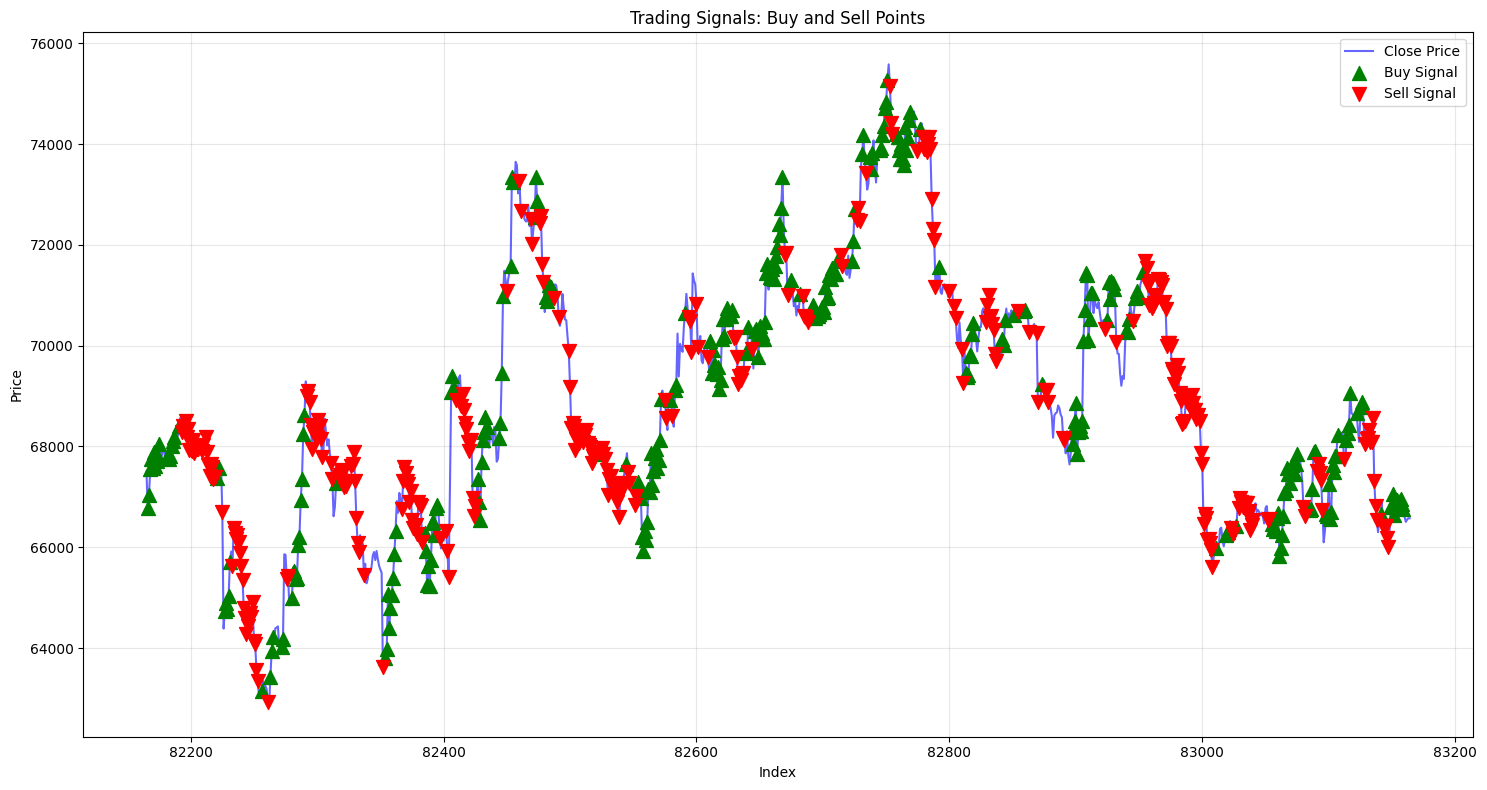


Signal Distribution:
Hold/No Action (0): 350
Buy Signals (1): 314
Sell Signals (2): 336


In [10]:

# Step 5: Visualize signals
print("\nStep 5: Visualizing trading signals...")
plot_signals(df[-1000:])



In [11]:
print(f"Data loaded: {len(df)} rows")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Data loaded: 83165 rows
Memory usage: 10.21 MB


In [12]:
df

,open,high,low,close,volume,month,day,hour,day_of_week,label,label_name,label_conf
0,0.830,0.900,0.830,0.870,14009,3,23,22,2,2,sell,0.402
1,0.870,0.890,0.860,0.880,4819,3,24,22,3,2,sell,0.402
2,0.880,0.910,0.840,0.860,11756,3,25,22,4,2,sell,0.454
3,0.830,0.870,0.820,0.820,5337,3,26,22,5,2,sell,0.303
4,0.820,0.850,0.760,0.800,12565,3,27,22,6,2,sell,0.368
...,...,...,...,...,...,...,...,...,...,...,...,...
83160,66760.733,66879.077,66450.813,66598.235,17486,4,3,1,4,0,hold,0.377
83161,66598.073,66725.484,66238.407,66503.268,19329,4,3,2,4,0,hold,0.354
83162,66503.268,66697.547,66459.543,66548.833,14980,4,3,3,4,0,hold,0.223
83163,66548.833,66664.871,66466.446,66576.988,14267,4,3,4,4,0,hold,0.219


In [13]:
# Prepare features and labels

feature_cols = ['open', 'high', 'low', 'close', 'volume',
                'hour', 'day', 'month','day_of_week']
                
X = df[feature_cols].values
y = df['label'].values
#df = None
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)
X , y = None, None



In [14]:
print(X_train.shape)

(74848, 9)


In [15]:
print("\n" + "="*70)
print("TRAINING CLASSIFICATION MODELS")
print("="*70)
model = RandomForestClassifier(n_estimators=300, n_jobs=2, random_state=42, verbose=2)
# Train
model.fit(X_train, y_train)
X_train, y_train = None, None
# Predict
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred)}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")


TRAINING CLASSIFICATION MODELS


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.


building tree 1 of 300
building tree 2 of 300
building tree 3 of 300
building tree 4 of 300
building tree 5 of 300
building tree 6 of 300
building tree 7 of 300
building tree 8 of 300
building tree 9 of 300
building tree 10 of 300
building tree 11 of 300
building tree 12 of 300
building tree 13 of 300
building tree 14 of 300
building tree 15 of 300
building tree 16 of 300
building tree 17 of 300
building tree 18 of 300
building tree 19 of 300
building tree 20 of 300
building tree 21 of 300
building tree 22 of 300
building tree 23 of 300
building tree 24 of 300
building tree 25 of 300
building tree 26 of 300
building tree 27 of 300
building tree 28 of 300
building tree 29 of 300
building tree 30 of 300
building tree 31 of 300
building tree 32 of 300
building tree 33 of 300
building tree 34 of 300
building tree 35 of 300
building tree 36 of 300
building tree 37 of 300
building tree 38 of 300
building tree 39 of 300


[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:   11.6s


building tree 40 of 300
building tree 41 of 300
building tree 42 of 300
building tree 43 of 300
building tree 44 of 300
building tree 45 of 300
building tree 46 of 300
building tree 47 of 300
building tree 48 of 300
building tree 49 of 300
building tree 50 of 300
building tree 51 of 300
building tree 52 of 300
building tree 53 of 300
building tree 54 of 300
building tree 55 of 300
building tree 56 of 300
building tree 57 of 300
building tree 58 of 300
building tree 59 of 300
building tree 60 of 300
building tree 61 of 300
building tree 62 of 300
building tree 63 of 300
building tree 64 of 300
building tree 65 of 300
building tree 66 of 300
building tree 67 of 300
building tree 68 of 300
building tree 69 of 300
building tree 70 of 300
building tree 71 of 300
building tree 72 of 300
building tree 73 of 300
building tree 74 of 300
building tree 75 of 300
building tree 76 of 300
building tree 77 of 300
building tree 78 of 300
building tree 79 of 300
building tree 80 of 300
building tree 81

[Parallel(n_jobs=2)]: Done 158 tasks      | elapsed:  1.0min


building tree 162 of 300
building tree 163 of 300
building tree 164 of 300
building tree 165 of 300
building tree 166 of 300
building tree 167 of 300
building tree 168 of 300
building tree 169 of 300
building tree 170 of 300
building tree 171 of 300
building tree 172 of 300
building tree 173 of 300
building tree 174 of 300
building tree 175 of 300
building tree 176 of 300
building tree 177 of 300
building tree 178 of 300
building tree 179 of 300
building tree 180 of 300
building tree 181 of 300
building tree 182 of 300
building tree 183 of 300
building tree 184 of 300
building tree 185 of 300
building tree 186 of 300
building tree 187 of 300
building tree 188 of 300
building tree 189 of 300
building tree 190 of 300
building tree 191 of 300
building tree 192 of 300
building tree 193 of 300
building tree 194 of 300
building tree 195 of 300
building tree 196 of 300
building tree 197 of 300
building tree 198 of 300
building tree 199 of 300
building tree 200 of 300
building tree 201 of 300


[Parallel(n_jobs=2)]: Done 300 out of 300 | elapsed:  1.6min finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 158 tasks      | elapsed:    0.2s


Accuracy: 0.7219

Confusion Matrix:
[[2207  473  426]
 [ 615 1997   94]
 [ 534  171 1800]]

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.71      0.68      3106
           1       0.76      0.74      0.75      2706
           2       0.78      0.72      0.75      2505

    accuracy                           0.72      8317
   macro avg       0.73      0.72      0.73      8317
weighted avg       0.73      0.72      0.72      8317



[Parallel(n_jobs=2)]: Done 300 out of 300 | elapsed:    0.4s finished


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 158 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 300 out of 300 | elapsed:    0.0s finished
e:\GitHub\Dbot-Advance\extra_function.py:625: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['predicted_label'] = model.predict(X)


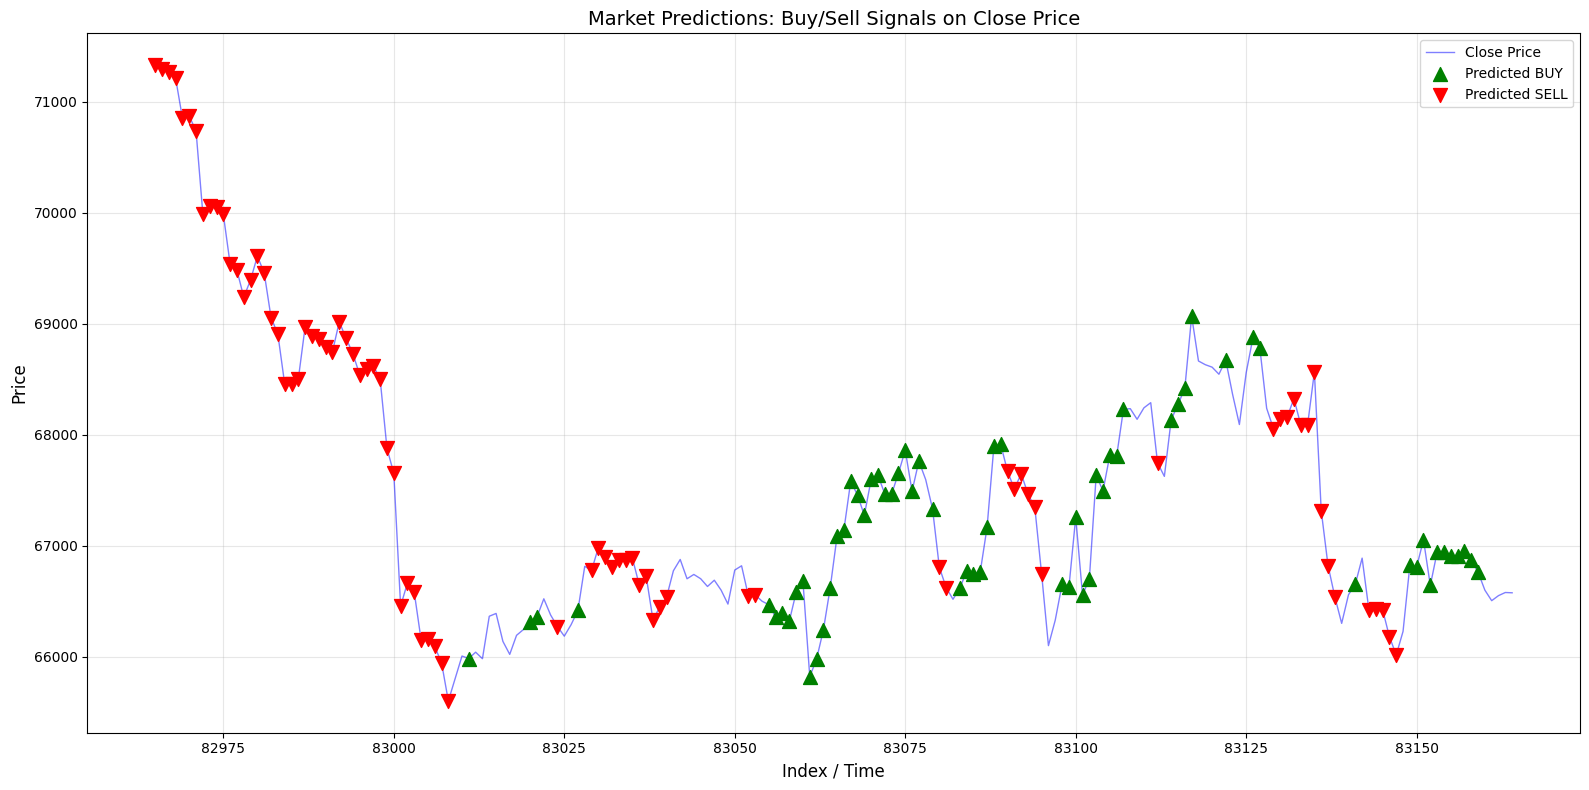


Signal Distribution:
Hold/No Action (0): 53
Buy Signals (1): 64
Sell Signals (2): 83


In [16]:

# --- Example Usage ---
# Ensure your 'df' has gone through engineer_features() first
# features = ['open', 'high', 'low', 'volume', 'month', 'day', 'hour', 'minute', 'day_of_week']
predict_and_plot_signals(model, df[-200:], feature_cols)